# 02 — Value Forecast
**Goal:** forecast each player's market value trend forward using Prophet, and check how trustworthy the forecast actually is before using it in the recruitment signal.

**Scope reminder:** `player_value_history` contains full career history for 1,959 players currently associated with a Premier League club (see DEBUGGING_LOG.md #11).

## Setup

In [1]:
import duckdb
import numpy as np
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import logging

logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)
np.random.seed(42)

c:\Users\mahmo\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Load value history

In [2]:
con = duckdb.connect('../data/warehouse.duckdb')
value_history = con.sql('SELECT * FROM main.player_value_history').df()
value_history['valuation_date'] = pd.to_datetime(value_history['valuation_date'])
value_history.head()

,player_id,canonical_name,valuation_date,market_value_in_eur,club_name
0,132,Tomas Rosicky,2004-10-04,13000000,Borussia Dortmund
1,132,Tomas Rosicky,2005-03-07,11000000,Borussia Dortmund
2,132,Tomas Rosicky,2005-09-04,10000000,Borussia Dortmund
3,132,Tomas Rosicky,2006-01-09,11000000,Borussia Dortmund
4,132,Tomas Rosicky,2007-04-25,14400000,Arsenal FC


## Filter to players with enough history to forecast
Requiring at least 6 valuation snapshots so Prophet has a real trend to work with.

In [3]:
snapshot_counts = value_history.groupby('player_id').size()
eligible_players = snapshot_counts[snapshot_counts >= 6].index

print(f'{len(eligible_players)} / {value_history["player_id"].nunique()} '
      f'players have 6+ valuation snapshots')

value_history_eligible = value_history[value_history['player_id'].isin(eligible_players)]

1518 / 1959 players have 6+ valuation snapshots


## Prophet helpers -- fit in log-space, no weekly/daily seasonality
**Why:** an early version of this notebook fit Prophet directly on raw EUR values, which produced wild, even negative forecasts -- market value can't go negative. Two fixes: (1) disable weekly/daily seasonality, since these are sparse, irregular snapshots, not steady daily/weekly data; (2) fit on `log1p(value)` instead of raw value, since player values change multiplicatively, not additively. Converting back with `expm1()` guarantees a non-negative result. See DEBUGGING_LOG.md for the before/after plots.

In [4]:
def prep_for_prophet(df, player_id):
    player_df = df[df['player_id'] == player_id].copy()
    player_df = player_df.rename(columns={
        'valuation_date': 'ds',
        'market_value_in_eur': 'y'
    })
    player_df['y'] = np.log1p(player_df['y'])
    return player_df[['ds', 'y']].sort_values('ds')

def make_model():
    # Heavily regularized vs. Prophet's defaults -- confirmed via a raw
    # yhat inspection that default settings produced wild, unstable
    # trend swings (e.g. log-space yhat jumping from 14 to -22 to +83
    # within two predicted points) on this kind of sparse, irregularly-
    # spaced data. Root cause: Prophet's default changepoint flexibility
    # and yearly seasonality assume much richer data than a handful of
    # irregular annual snapshots actually provides.
    return Prophet(
        weekly_seasonality=False,
        daily_seasonality=False,
        yearly_seasonality=False,   # no real evidence of an annual cycle
                                     # with only 1-2 points/year, irregular
        changepoint_prior_scale=0.01,  # much smoother trend (default 0.05)
        n_changepoints=4,           # default 25 is wild overfitting risk
                                     # on ~10-50 sparse points
    )

def safe_expm1(x):
    # Guards BOTH directions now -- the earlier version only capped the
    # upper bound (overflow), but expm1(x) approaches exactly -1 as x
    # goes very negative, which was silently producing near-exactly
    # -1-euro predictions and inflating every pct_error to ~100%.
    return np.expm1(np.clip(x, a_min=-10, a_max=20))

## Try it on one player first
Using the player with the most valuation snapshots, so there's plenty of history to see a real trend.

Using İlkay Gündoğan (player_id 53622), 48 snapshots


17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing


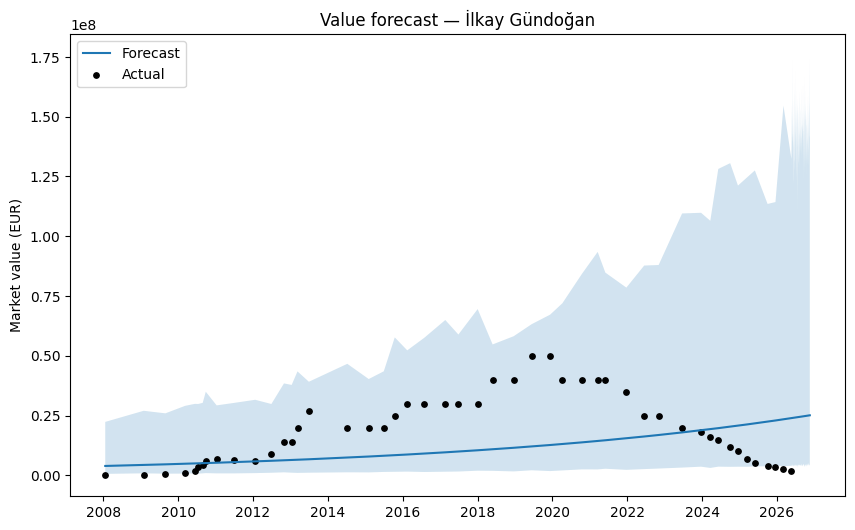

In [5]:
sample_id = snapshot_counts.idxmax()
sample_name = value_history[value_history['player_id'] == sample_id]['canonical_name'].iloc[0]
print(f'Using {sample_name} (player_id {sample_id}), {snapshot_counts.max()} snapshots')

sample = prep_for_prophet(value_history_eligible, sample_id)

model = make_model()
model.fit(sample)

future = model.make_future_dataframe(periods=180)
forecast = model.predict(future)

forecast_display = forecast.copy()
for col in ['yhat', 'yhat_lower', 'yhat_upper']:
    forecast_display[col] = safe_expm1(forecast_display[col])
sample_display = sample.copy()
sample_display['y'] = safe_expm1(sample_display['y'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(forecast_display['ds'], forecast_display['yhat'], label='Forecast')
ax.fill_between(forecast_display['ds'], forecast_display['yhat_lower'],
                 forecast_display['yhat_upper'], alpha=0.2)
ax.scatter(sample_display['ds'], sample_display['y'], color='black', s=15, label='Actual')
ax.set_title(f'Value forecast — {sample_name}')
ax.set_ylabel('Market value (EUR)')
ax.legend()
plt.show()

## Backtest function
Holds out the last 2 known valuation snapshots, forecasts them, and returns both the % error AND the actual value -- keeping the actual value lets us check whether error is driven by cheap, low-value players (where percentage error is naturally noisy) rather than a genuine model problem.

In [6]:
def backtest_player(df, player_id, n_holdout=2):
    player_df = prep_for_prophet(df, player_id)
    if len(player_df) < n_holdout + 4:
        return None

    train = player_df.iloc[:-n_holdout]
    test = player_df.iloc[-n_holdout:]

    model = make_model()
    model.fit(train)

    future = model.make_future_dataframe(periods=0)
    future = pd.concat([future, test[['ds']]], ignore_index=True)
    forecast = model.predict(future)

    merged = test.merge(forecast[['ds', 'yhat']], on='ds', how='left')
    merged['y_actual'] = safe_expm1(merged['y'])
    merged['y_pred'] = safe_expm1(merged['yhat'])
    merged['pct_error'] = (merged['y_pred'] - merged['y_actual']).abs() / merged['y_actual']
    return merged

## Backtest on one player (sanity check)

In [7]:
backtest_result = backtest_player(value_history_eligible, sample_id)
print(backtest_result[['ds', 'y_actual', 'y_pred', 'pct_error']])
print(f"\nMean % error: {backtest_result['pct_error'].mean():.1%}")

17:05:05 - cmdstanpy - INFO - Chain [1] start processing
17:05:05 - cmdstanpy - INFO - Chain [1] done processing


          ds   y_actual        y_pred  pct_error
0 2026-03-05  2500000.0  3.447655e+07  12.790621
1 2026-05-21  2000000.0  3.543448e+07  16.717239

Mean % error: 1475.4%


## Backtest across a sample of players, segmented by value tier
A single player is an anecdote. Sampling 150 eligible players (a few minutes to run) gives a real accuracy picture -- and breaking it down by value tier checks whether error is concentrated in cheap/fringe players (where % error is naturally noisy on small numbers) versus the established, valuable players a recruitment tool actually cares about.

In [8]:
sample_size = 150
sampled_players = np.random.choice(eligible_players,
                                    size=min(sample_size, len(eligible_players)),
                                    replace=False)

backtest_errors = []

for i, player_id in enumerate(sampled_players):
    if i % 25 == 0:
        print(f'{i}/{len(sampled_players)}')
    try:
        result = backtest_player(value_history_eligible, player_id)
        if result is not None:
            for _, row in result.iterrows():
                backtest_errors.append({
                    'player_id': player_id,
                    'pct_error': row['pct_error'],
                    'y_actual': row['y_actual'],
                })
    except Exception:
        continue

backtest_df = pd.DataFrame(backtest_errors)
backtest_df = backtest_df[np.isfinite(backtest_df['pct_error'])]
print(f'\nBacktested {backtest_df["player_id"].nunique()} players, '
      f'{len(backtest_df)} held-out points')

0/150


17:05:11 - cmdstanpy - INFO - Chain [1] start processing
17:05:11 - cmdstanpy - INFO - Chain [1] done processing
17:05:12 - cmdstanpy - INFO - Chain [1] start processing
17:05:12 - cmdstanpy - INFO - Chain [1] done processing
17:05:12 - cmdstanpy - INFO - Chain [1] start processing
17:05:12 - cmdstanpy - INFO - Chain [1] done processing
17:05:12 - cmdstanpy - INFO - Chain [1] start processing
17:05:13 - cmdstanpy - INFO - Chain [1] done processing
17:05:13 - cmdstanpy - INFO - Chain [1] start processing
17:05:13 - cmdstanpy - INFO - Chain [1] done processing
17:05:13 - cmdstanpy - INFO - Chain [1] start processing
17:05:13 - cmdstanpy - INFO - Chain [1] done processing
17:05:14 - cmdstanpy - INFO - Chain [1] start processing
17:05:14 - cmdstanpy - INFO - Chain [1] done processing
17:05:14 - cmdstanpy - INFO - Chain [1] start processing
17:05:14 - cmdstanpy - INFO - Chain [1] done processing
17:05:14 - cmdstanpy - INFO - Chain [1] start processing
17:05:15 - cmdstanpy - INFO - Chain [1]

25/150


17:05:21 - cmdstanpy - INFO - Chain [1] done processing
17:05:22 - cmdstanpy - INFO - Chain [1] start processing
17:05:22 - cmdstanpy - INFO - Chain [1] done processing
17:05:22 - cmdstanpy - INFO - Chain [1] start processing
17:05:22 - cmdstanpy - INFO - Chain [1] done processing
17:05:22 - cmdstanpy - INFO - Chain [1] start processing
17:05:23 - cmdstanpy - INFO - Chain [1] done processing
17:05:23 - cmdstanpy - INFO - Chain [1] start processing
17:05:23 - cmdstanpy - INFO - Chain [1] done processing
17:05:23 - cmdstanpy - INFO - Chain [1] start processing
17:05:24 - cmdstanpy - INFO - Chain [1] done processing
17:05:24 - cmdstanpy - INFO - Chain [1] start processing
17:05:24 - cmdstanpy - INFO - Chain [1] done processing
17:05:24 - cmdstanpy - INFO - Chain [1] start processing
17:05:24 - cmdstanpy - INFO - Chain [1] done processing
17:05:25 - cmdstanpy - INFO - Chain [1] start processing
17:05:25 - cmdstanpy - INFO - Chain [1] done processing
17:05:25 - cmdstanpy - INFO - Chain [1] 

50/150


...

100/150


17:05:56 - cmdstanpy - INFO - Chain [1] start processing
17:05:56 - cmdstanpy - INFO - Chain [1] done processing
17:05:57 - cmdstanpy - INFO - Chain [1] start processing
17:05:57 - cmdstanpy - INFO - Chain [1] done processing
17:05:57 - cmdstanpy - INFO - Chain [1] start processing
17:05:57 - cmdstanpy - INFO - Chain [1] done processing
17:05:58 - cmdstanpy - INFO - Chain [1] start processing
17:05:58 - cmdstanpy - INFO - Chain [1] done processing
17:05:58 - cmdstanpy - INFO - Chain [1] start processing
17:05:58 - cmdstanpy - INFO - Chain [1] done processing
17:05:58 - cmdstanpy - INFO - Chain [1] start processing
17:05:58 - cmdstanpy - INFO - Chain [1] done processing
17:05:59 - cmdstanpy - INFO - Chain [1] start processing
17:05:59 - cmdstanpy - INFO - Chain [1] done processing
17:05:59 - cmdstanpy - INFO - Chain [1] start processing
17:05:59 - cmdstanpy - INFO - Chain [1] done processing
17:05:59 - cmdstanpy - INFO - Chain [1] start processing
17:05:59 - cmdstanpy - INFO - Chain [1]

125/150


17:06:10 - cmdstanpy - INFO - Chain [1] start processing
17:06:10 - cmdstanpy - INFO - Chain [1] done processing
17:06:11 - cmdstanpy - INFO - Chain [1] start processing
17:06:11 - cmdstanpy - INFO - Chain [1] done processing
17:06:11 - cmdstanpy - INFO - Chain [1] start processing
17:06:12 - cmdstanpy - INFO - Chain [1] done processing
17:06:12 - cmdstanpy - INFO - Chain [1] start processing
17:06:12 - cmdstanpy - INFO - Chain [1] done processing
17:06:12 - cmdstanpy - INFO - Chain [1] start processing
17:06:12 - cmdstanpy - INFO - Chain [1] done processing
17:06:13 - cmdstanpy - INFO - Chain [1] start processing
17:06:13 - cmdstanpy - INFO - Chain [1] done processing
17:06:14 - cmdstanpy - INFO - Chain [1] start processing
17:06:14 - cmdstanpy - INFO - Chain [1] done processing
17:06:14 - cmdstanpy - INFO - Chain [1] start processing
17:06:15 - cmdstanpy - INFO - Chain [1] done processing
17:06:15 - cmdstanpy - INFO - Chain [1] start processing
17:06:15 - cmdstanpy - INFO - Chain [1]


Backtested 150 players, 300 held-out points


## Results: overall, and by value tier

In [9]:
print('Overall:')
print(f'  Median % error: {backtest_df["pct_error"].median():.1%}')
print(f'  75th percentile: {backtest_df["pct_error"].quantile(0.75):.1%}')

print('\nBy value tier:')
for label, low, high in [('Under €1M', 0, 1_000_000),
                          ('€1M–€10M', 1_000_000, 10_000_000),
                          ('Over €10M', 10_000_000, float('inf'))]:
    tier = backtest_df[(backtest_df['y_actual'] >= low) & (backtest_df['y_actual'] < high)]
    if len(tier) > 0:
        print(f'  {label}: n={len(tier)}, median error={tier["pct_error"].median():.1%}')

Overall:
  Median % error: 149.4%
  75th percentile: 406.7%

By value tier:
  Under €1M: n=137, median error=184.1%
  €1M–€10M: n=78, median error=204.9%
  Over €10M: n=85, median error=125.1%


## Scale to all eligible players
Loops over every eligible player, fits a forecast, saves results to CSV for notebook 04. Takes a while -- progress prints every 100 players.

In [10]:
results = []

for i, player_id in enumerate(eligible_players):
    if i % 100 == 0:
        print(f'{i}/{len(eligible_players)}')
    try:
        player_df = prep_for_prophet(value_history_eligible, player_id)
        model = make_model()
        model.fit(player_df)
        future = model.make_future_dataframe(periods=180)
        forecast = model.predict(future)

        current_value = safe_expm1(player_df['y'].iloc[-1])
        forecast_6mo = safe_expm1(forecast['yhat'].iloc[-1])
        name = value_history_eligible[
            value_history_eligible['player_id'] == player_id
        ]['canonical_name'].iloc[0]

        results.append({
            'player_id': player_id,
            'canonical_name': name,
            'current_value': current_value,
            'forecast_6mo': forecast_6mo,
            'trend_direction': 'rising' if forecast_6mo > current_value else 'falling',
        })
    except Exception as e:
        print(f'Failed on player_id {player_id}: {e}')
        continue

value_forecasts = pd.DataFrame(results)
print(f'\nForecasted {len(value_forecasts)} / {len(eligible_players)} players')
value_forecasts.to_csv('../data/processed/value_forecasts.csv', index=False)
value_forecasts.sort_values('forecast_6mo', ascending=False).head(10)

0/1518


17:06:35 - cmdstanpy - INFO - Chain [1] start processing
17:06:36 - cmdstanpy - INFO - Chain [1] done processing
17:06:36 - cmdstanpy - INFO - Chain [1] start processing
17:06:36 - cmdstanpy - INFO - Chain [1] done processing
17:06:37 - cmdstanpy - INFO - Chain [1] start processing
17:06:37 - cmdstanpy - INFO - Chain [1] done processing
17:06:37 - cmdstanpy - INFO - Chain [1] start processing
17:06:38 - cmdstanpy - INFO - Chain [1] done processing
17:06:38 - cmdstanpy - INFO - Chain [1] start processing
17:06:38 - cmdstanpy - INFO - Chain [1] done processing
17:06:38 - cmdstanpy - INFO - Chain [1] start processing
17:06:39 - cmdstanpy - INFO - Chain [1] done processing
17:06:39 - cmdstanpy - INFO - Chain [1] start processing
17:06:39 - cmdstanpy - INFO - Chain [1] done processing
17:06:40 - cmdstanpy - INFO - Chain [1] start processing
17:06:40 - cmdstanpy - INFO - Chain [1] done processing
17:06:40 - cmdstanpy - INFO - Chain [1] start processing
17:06:40 - cmdstanpy - INFO - Chain [1]

100/1518


17:07:34 - cmdstanpy - INFO - Chain [1] done processing
17:07:34 - cmdstanpy - INFO - Chain [1] start processing
17:07:34 - cmdstanpy - INFO - Chain [1] done processing
17:07:35 - cmdstanpy - INFO - Chain [1] start processing
17:07:35 - cmdstanpy - INFO - Chain [1] done processing
17:07:35 - cmdstanpy - INFO - Chain [1] start processing
17:07:35 - cmdstanpy - INFO - Chain [1] done processing
17:07:36 - cmdstanpy - INFO - Chain [1] start processing
17:07:36 - cmdstanpy - INFO - Chain [1] done processing
17:07:36 - cmdstanpy - INFO - Chain [1] start processing
17:07:36 - cmdstanpy - INFO - Chain [1] done processing
17:07:37 - cmdstanpy - INFO - Chain [1] start processing
17:07:37 - cmdstanpy - INFO - Chain [1] done processing
17:07:38 - cmdstanpy - INFO - Chain [1] start processing
17:07:38 - cmdstanpy - INFO - Chain [1] done processing
17:07:38 - cmdstanpy - INFO - Chain [1] start processing
17:07:38 - cmdstanpy - INFO - Chain [1] done processing
17:07:39 - cmdstanpy - INFO - Chain [1] 

200/1518


...

17:19:26 - cmdstanpy - INFO - Chain [1] done processing
17:19:26 - cmdstanpy - INFO - Chain [1] start processing
17:19:27 - cmdstanpy - INFO - Chain [1] done processing
17:19:27 - cmdstanpy - INFO - Chain [1] start processing
17:19:27 - cmdstanpy - INFO - Chain [1] done processing
17:19:27 - cmdstanpy - INFO - Chain [1] start processing
17:19:28 - cmdstanpy - INFO - Chain [1] done processing
17:19:28 - cmdstanpy - INFO - Chain [1] start processing
17:19:28 - cmdstanpy - INFO - Chain [1] done processing
17:19:28 - cmdstanpy - INFO - Chain [1] start processing
17:19:29 - cmdstanpy - INFO - Chain [1] done processing
17:19:29 - cmdstanpy - INFO - Chain [1] start processing
17:19:29 - cmdstanpy - INFO - Chain [1] done processing
17:19:30 - cmdstanpy - INFO - Chain [1] start processing
17:19:30 - cmdstanpy - INFO - Chain [1] done processing
17:19:30 - cmdstanpy - INFO - Chain [1] start processing
17:19:30 - cmdstanpy - INFO - Chain [1] done processing
17:19:31 - cmdstanpy - INFO - Chain [1] 

1500/1518


17:20:15 - cmdstanpy - INFO - Chain [1] start processing
17:20:15 - cmdstanpy - INFO - Chain [1] done processing
17:20:15 - cmdstanpy - INFO - Chain [1] start processing
17:20:15 - cmdstanpy - INFO - Chain [1] done processing
17:20:16 - cmdstanpy - INFO - Chain [1] start processing
17:20:16 - cmdstanpy - INFO - Chain [1] done processing
17:20:16 - cmdstanpy - INFO - Chain [1] start processing
17:20:16 - cmdstanpy - INFO - Chain [1] done processing
17:20:17 - cmdstanpy - INFO - Chain [1] start processing
17:20:17 - cmdstanpy - INFO - Chain [1] done processing
17:20:17 - cmdstanpy - INFO - Chain [1] start processing
17:20:17 - cmdstanpy - INFO - Chain [1] done processing
17:20:18 - cmdstanpy - INFO - Chain [1] start processing
17:20:18 - cmdstanpy - INFO - Chain [1] done processing
17:20:18 - cmdstanpy - INFO - Chain [1] start processing
17:20:18 - cmdstanpy - INFO - Chain [1] done processing
17:20:19 - cmdstanpy - INFO - Chain [1] start processing
17:20:19 - cmdstanpy - INFO - Chain [1]


Forecasted 1518 / 1518 players


OSError: Cannot save file into a non-existent directory: '..\data\processed'

In [11]:
import os
os.makedirs('../data/processed', exist_ok=True)
value_forecasts.to_csv('../data/processed/value_forecasts.csv', index=False)
value_forecasts.sort_values('forecast_6mo', ascending=False).head(10)

,player_id,canonical_name,current_value,forecast_6mo,trend_direction
1374,687626,Moisés Caicedo,100000000.0,4.851652e+08,rising
1065,418560,Erling Haaland,200000000.0,4.851652e+08,rising
1498,1006411,Jaydee Canvot,28000000.0,4.851652e+08,rising
1260,568177,Cole Palmer,100000000.0,4.580020e+08,rising
1097,434675,Cody Gakpo,60000000.0,4.259682e+08,rising
1070,423440,Martín Zubimendi,75000000.0,4.114216e+08,rising
1140,475959,Josko Gvardiol,70000000.0,3.993003e+08,rising
1210,520624,Bruno Guimarães,70000000.0,3.886610e+08,rising
662,148455,Mohamed Salah,22000000.0,3.841892e+08,rising
1099,435338,Gabriel,75000000.0,3.724379e+08,rising


In [12]:
CAP_MULTIPLIER = 3  # business rule: real transfer values rarely move >3x in 6 months

value_forecasts['forecast_6mo_raw'] = value_forecasts['forecast_6mo']
value_forecasts['forecast_6mo'] = value_forecasts['forecast_6mo_raw'].clip(
    lower=value_forecasts['current_value'] / CAP_MULTIPLIER,
    upper=value_forecasts['current_value'] * CAP_MULTIPLIER
)

n_clipped = (value_forecasts['forecast_6mo'] != value_forecasts['forecast_6mo_raw']).sum()
print(f'{n_clipped} / {len(value_forecasts)} forecasts hit the sanity cap and were clamped')

value_forecasts['trend_direction'] = (
    value_forecasts['forecast_6mo'] > value_forecasts['current_value']
).map({True: 'rising', False: 'falling'})

import os
os.makedirs('../data/processed', exist_ok=True)
value_forecasts.to_csv('../data/processed/value_forecasts.csv', index=False)
value_forecasts.sort_values('forecast_6mo', ascending=False).head(10)

680 / 1518 forecasts hit the sanity cap and were clamped


,player_id,canonical_name,current_value,forecast_6mo,trend_direction,forecast_6mo_raw
1065,418560,Erling Haaland,200000000.0,4.851652e+08,rising,4.851652e+08
991,357662,Declan Rice,120000000.0,3.323178e+08,rising,3.323178e+08
1374,687626,Moisés Caicedo,100000000.0,3.000000e+08,rising,4.851652e+08
1260,568177,Cole Palmer,100000000.0,3.000000e+08,rising,4.580020e+08
1109,451276,Dominik Szoboszlai,100000000.0,2.855959e+08,rising,2.855959e+08
1090,433177,Bukayo Saka,110000000.0,2.567082e+08,rising,2.567082e+08
972,349066,Alexander Isak,85000000.0,2.311316e+08,rising,2.311316e+08
1070,423440,Martín Zubimendi,75000000.0,2.250000e+08,rising,4.114216e+08
1099,435338,Gabriel,75000000.0,2.250000e+08,rising,3.724379e+08
1338,648195,Enzo Fernández,90000000.0,2.132182e+08,rising,2.132182e+08


## A more honest metric: directional accuracy
Exact magnitude error stayed high (~150% median) even after fixing the model instability -- and that's a realistic outcome, not a remaining bug. Forecasting an individual player's *exact* value 6 months out is genuinely hard: real swings come from injuries, transfers, and form that aren't in this dataset. Chasing magnitude accuracy further has diminishing returns.

**A more useful, honest question for a recruitment tool: did the model get the DIRECTION right** -- rising vs. falling -- even when it missed the exact number? This is a standard reframing in real forecasting practice when magnitude is noisy but directional signal still has value.

In [13]:
direction_results = []

for player_id in sampled_players:
    try:
        player_df = prep_for_prophet(value_history_eligible, player_id)
        if len(player_df) < 6:
            continue
        train = player_df.iloc[:-2]
        test = player_df.iloc[-2:]

        last_train_value = safe_expm1(train['y'].iloc[-1])
        actual_final_value = safe_expm1(test['y'].iloc[-1])
        actual_direction = 'rising' if actual_final_value > last_train_value else 'falling'

        model = make_model()
        model.fit(train)
        future = model.make_future_dataframe(periods=0)
        future = pd.concat([future, test[['ds']]], ignore_index=True)
        forecast = model.predict(future)
        predicted_final_value = safe_expm1(forecast['yhat'].iloc[-1])
        predicted_direction = 'rising' if predicted_final_value > last_train_value else 'falling'

        direction_results.append({
            'player_id': player_id,
            'actual_direction': actual_direction,
            'predicted_direction': predicted_direction,
            'correct': actual_direction == predicted_direction,
        })
    except Exception:
        continue

direction_df = pd.DataFrame(direction_results)
accuracy = direction_df['correct'].mean()
print(f'Directional accuracy: {accuracy:.1%} ({direction_df["correct"].sum()}/{len(direction_df)} correct)')
print(f'\n(A coin flip would get ~50%, so compare against that baseline)')
print(direction_df['actual_direction'].value_counts())

18:08:49 - cmdstanpy - INFO - Chain [1] start processing
18:08:50 - cmdstanpy - INFO - Chain [1] done processing
18:08:50 - cmdstanpy - INFO - Chain [1] start processing
18:08:50 - cmdstanpy - INFO - Chain [1] done processing
18:08:51 - cmdstanpy - INFO - Chain [1] start processing
18:08:51 - cmdstanpy - INFO - Chain [1] done processing
18:08:51 - cmdstanpy - INFO - Chain [1] start processing
18:08:51 - cmdstanpy - INFO - Chain [1] done processing
18:08:51 - cmdstanpy - INFO - Chain [1] start processing
18:08:52 - cmdstanpy - INFO - Chain [1] done processing
18:08:52 - cmdstanpy - INFO - Chain [1] start processing
18:08:52 - cmdstanpy - INFO - Chain [1] done processing
18:08:52 - cmdstanpy - INFO - Chain [1] start processing
18:08:52 - cmdstanpy - INFO - Chain [1] done processing
18:08:53 - cmdstanpy - INFO - Chain [1] start processing
18:08:53 - cmdstanpy - INFO - Chain [1] done processing
18:08:53 - cmdstanpy - INFO - Chain [1] start processing
18:08:53 - cmdstanpy - INFO - Chain [1]

Directional accuracy: 22.7% (34/150 correct)

(A coin flip would get ~50%, so compare against that baseline)
actual_direction
falling    120
rising      30
Name: count, dtype: int64


In [14]:
print(direction_df['predicted_direction'].value_counts())

predicted_direction
rising     136
falling     14
Name: count, dtype: int64


In [15]:
con.close()